# STEP 1: Data Collection

##### **Import the required libraries** - for a start, those that help with data importation and exploration - numpy, pandas, matplotlib, seaborn

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
import os

##### **Data Ingestion**  - Ingestion of the Breast Cancer Dataset from Wisconsin Diagnostic

In [89]:
import pandas as pd
file_path = r'C:\Users\Kayode Ogunyemi\Downloads\breast_cancer_data.csv'
print("File exists:", os.path.exists(file_path))

#Ingest the Data into a data frame
dataset = pd.read_csv(file_path)
print("Dataset shape:", dataset.shape)
dataset.head()


File exists: True
Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [90]:
## Reviewed all the 32 Columns in the Dataset
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

# STEP 1B: Data Cleaning

##### **Data Cleaning**  - Checked for duplicated records,Handling missing values,incorrect data types and identifying errorneous outliers

In [91]:
# Remove unnecessary columns such as ID, UNNAMED
dataset = dataset.drop(columns=['id', 'Unnamed: 32'])

# Check missing values
print(dataset.isnull().sum())

# Check duplicates
print(dataset.duplicated().sum())

# Standardize diagnosis values
dataset['diagnosis'] = dataset['diagnosis'].str.strip().str.upper()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64
0


In [92]:
# Investigated Potential Outliers using IQR to handle provided Dataset
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outliers = ((X < (Q1 - 1.5 * IQR)) |
            (X > (Q3 + 1.5 * IQR))).sum()

print("Potential outliers by feature:")
print(outliers.sort_values(ascending=False))


Potential outliers by feature:
area_se                    65
radius_se                  38
perimeter_se               38
area_worst                 35
smoothness_se              30
fractal_dimension_se       28
compactness_se             28
symmetry_se                27
area_mean                  25
fractal_dimension_worst    24
symmetry_worst             23
concavity_se               22
texture_se                 20
concave points_se          19
concavity_mean             18
radius_worst               17
compactness_worst          16
compactness_mean           16
symmetry_mean              15
fractal_dimension_mean     15
perimeter_worst            15
radius_mean                14
perimeter_mean             13
concavity_worst            12
concave points_mean        10
texture_mean                7
smoothness_worst            7
smoothness_mean             6
texture_worst               5
concave points_worst        0
dtype: int64


##### **INTERPRETATION** - Potential outliers were identified using the Interquartile Range (IQR) method. As shown above, several features, particularly area_se, radius_se, perimeter_se, and area_worst, contained observations outside the conventional 1.5 × IQR boundaries. However, i retained these observation because the dataset represents biological measurements and extreme values may reflect genuine differences in tumor characteristics rather than errors. Removing them could eliminate clinically meaningful information and negatively affect the predictive model.

# STEP 2: Data Preprocessing

Step 2A - Encoding the indentified target variable: DIAGNOSIS ( M=1,B=0)

In [93]:
# Convert diagnosis to numerical values
y = dataset['diagnosis'].map({'M': 1, 'B': 0})
print(y)


0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64


Step 2B - Seperating the features and target by splitting the dataset into FEATURES(x) - variables to make predictions, TARGET(y) - the variable we try to predict

In [94]:
# Separate features and target
X = dataset.drop(columns=['diagnosis'])
y = dataset['diagnosis'].map({'M': 1, 'B': 0})

# Check the results
print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts())

print("Missing values in X:", X.isnull().sum().sum())
print("Missing values in y:", y.isnull().sum())


Features (X) shape: (569, 30)
Target (y) shape: (569,)

Feature columns:
['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']

Target distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64
Missing values in X: 0
Missing values in y: 0


Step 2C - Splitting Data. I used stratify=y such that the proportion of malignant and benign cases remains similar in both datasets

In [95]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


##### ****INTERPRETATION**** - All checks came out clean without missing values

Step 2D - Standardization of Features - This is required to standardized all the 30 FEATURES in this dataset in preparation for tensorflow . Fit transformation was used to avoid data leakage

In [96]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()
# Fit ONLY on training data and transform training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the scaler fitted on training data
X_test_scaled = scaler.transform(X_test)

print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)


Scaled training data shape: (455, 30)
Scaled testing data shape: (114, 30)


In [97]:
### Verify the scaling ( The MEAN is approximately 0 and the STANDARD DEVIATION is approximately 1
print("Mean of scaled training features:")
print(np.mean(X_train_scaled, axis=0))

print("\nStandard deviation of scaled training features:")
print(np.std(X_train_scaled, axis=0))

Mean of scaled training features:
[-1.73731603e-16  3.90408097e-16  4.70441756e-16 -1.17122429e-16
  7.24207019e-16 -5.07530526e-17 -4.48969311e-17  2.92806072e-17
  2.34244858e-17  3.66983611e-16  1.67875482e-16 -8.97938622e-17
 -2.49861182e-16  1.44450996e-16 -1.56163239e-16 -1.56163239e-17
  4.68489716e-17 -1.40546915e-16  8.58897812e-17 -2.34244858e-17
 -3.96264218e-16  2.18628534e-16 -2.98662194e-16 -1.56163239e-17
 -1.52259158e-16 -1.13218348e-16 -4.48969311e-17  3.02566275e-17
 -4.84106040e-16  3.00614234e-16]

Standard deviation of scaled training features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


# STEP 3: Data Exploration(Visualization)

Understanding the distribution of the target variable, relationship between important features. Most importantly, to understand whether the target classes are balanced.

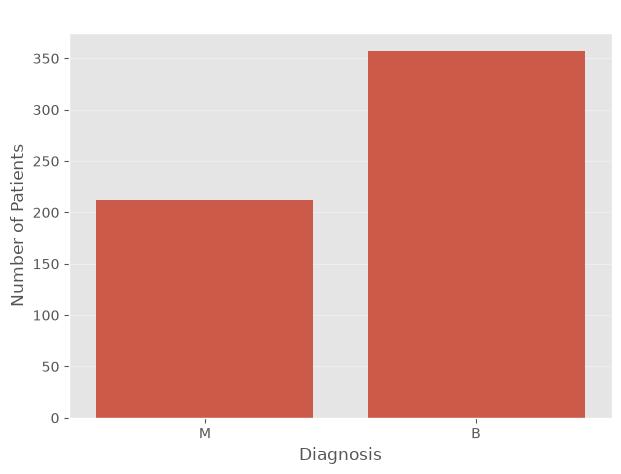

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.countplot(data=dataset, x='diagnosis')

plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.show()

This visualisation is understand to see whether malignant and benign cases have different distributions of mean tumor radius.

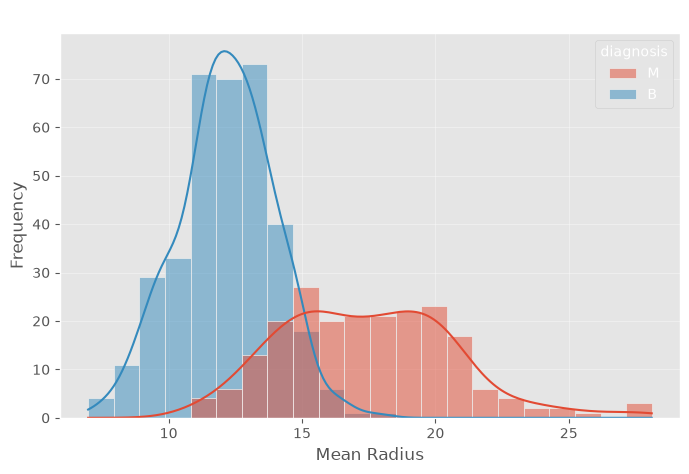

In [99]:
plt.figure(figsize=(8, 5))
sns.histplot(data=dataset,x='radius_mean',hue='diagnosis',kde=True)

plt.title('Distribution of Mean Radius by Diagnosis')
plt.xlabel('Mean Radius')
plt.ylabel('Frequency')
plt.show()

INTERPRETATION - The visualization of radius_mean shows a noticeable difference between benign and malignant tumors.                                                            Malignant cases generally have higher mean radius measurements than benign cases, suggesting that tumor size is an important predictor of malignancy. _However, there is some overlap between the two distributions, indicating that radius_mean alone is insufficient for accurate classification_. The presence of higher-radius observations also explains some of the potential outliers identified during the data-preprocessing stage. Therefore, radius_mean is likely to provide useful information to the machine-learning model when combined with other tumor characteristics.

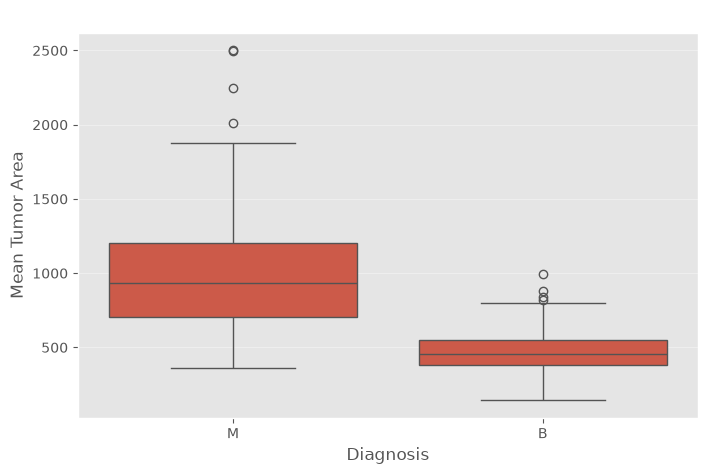

In [100]:
# TO understand outliers better. This analysis is required
plt.figure(figsize=(8, 5))

sns.boxplot(data=dataset,x='diagnosis',y='area_mean')
plt.title('Mean Tumor Area by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Mean Tumor Area')
plt.show()

INTERPRETATION - The boxplot comparison of area_mean reveals a clear difference between benign and malignant tumors. Malignant tumors generally have higher mean area values, with a higher median and a wider overall distribution compared with benign tumors. Several observations appear beyond the whiskers, indicating potential outliers; however, these values were retained because they may represent genuine variations in tumor characteristics rather than errors. The overlap between the two groups indicates that area_mean alone is not sufficient to classify tumors accurately. Nevertheless, its noticeable difference between the two diagnosis classes suggests that it is an important predictive feature for the machine-learning model.

I visualized AREA_SE which had the highest number of potential IQR outliers to understand whether the extreme values are concentrated in one diagnosis class

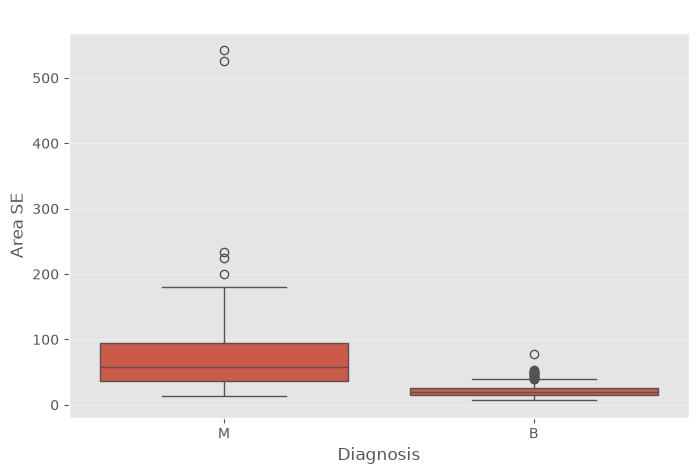

In [101]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=dataset,x='diagnosis',y='area_se')

plt.title('Area Standard Error by Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Area SE')
plt.show()

Its also important the visualize the relation between important features especially between TUMOR RADIUS and AREA

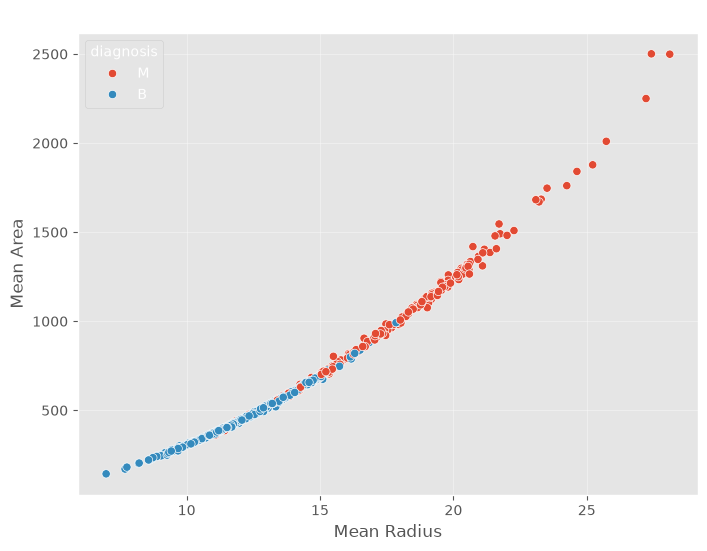

In [102]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=dataset,x='radius_mean',y='area_mean',hue='diagnosis')

plt.title('Mean Radius vs Mean Area')
plt.xlabel('Mean Radius')
plt.ylabel('Mean Area')
plt.show()

INTERPRETATION - From the chart above, suggest there is strong relationship between tumor radius and area.

Correlation Heatmap - Because the dataset contains 30 numerical features, a correlation map will be useful to understand correlated features such as RADIUS_MEAN and PERIMETER_MEAN

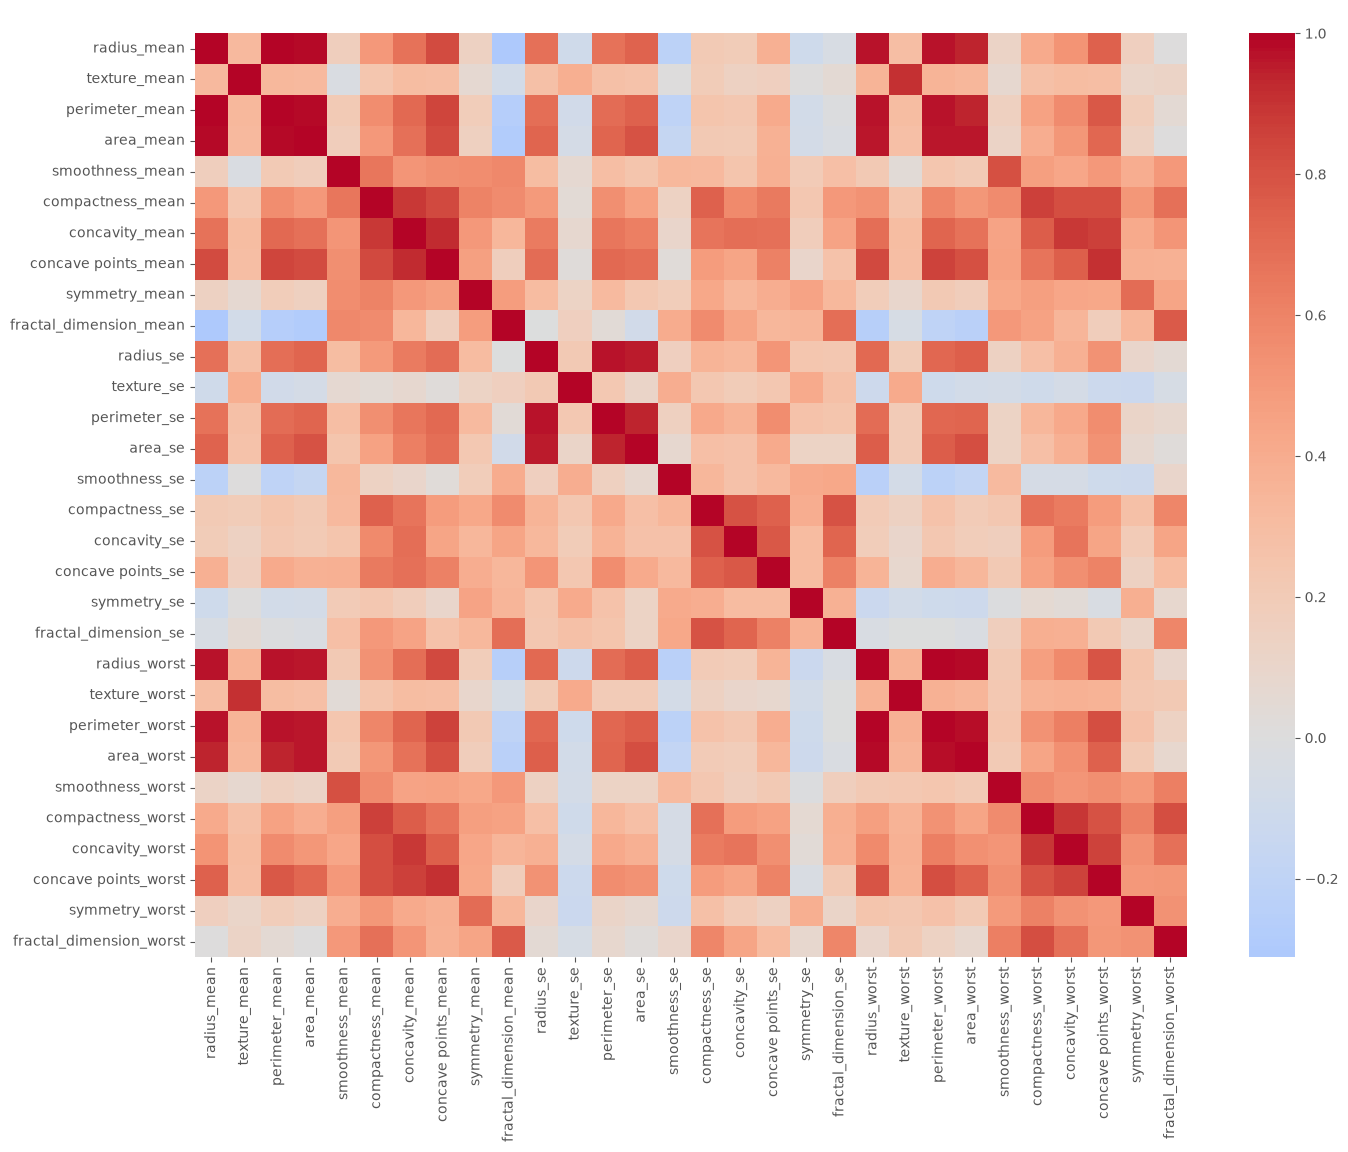

In [103]:
plt.figure(figsize=(16, 12))

correlation_matrix = dataset.drop(columns=['diagnosis']).corr()
sns.heatmap(correlation_matrix,cmap='coolwarm',center=0)

plt.title('Feature Correlation Heatmap')
plt.show()

**Pairplot of selected features** - Instead of plotting all 30 variables, select a few important features

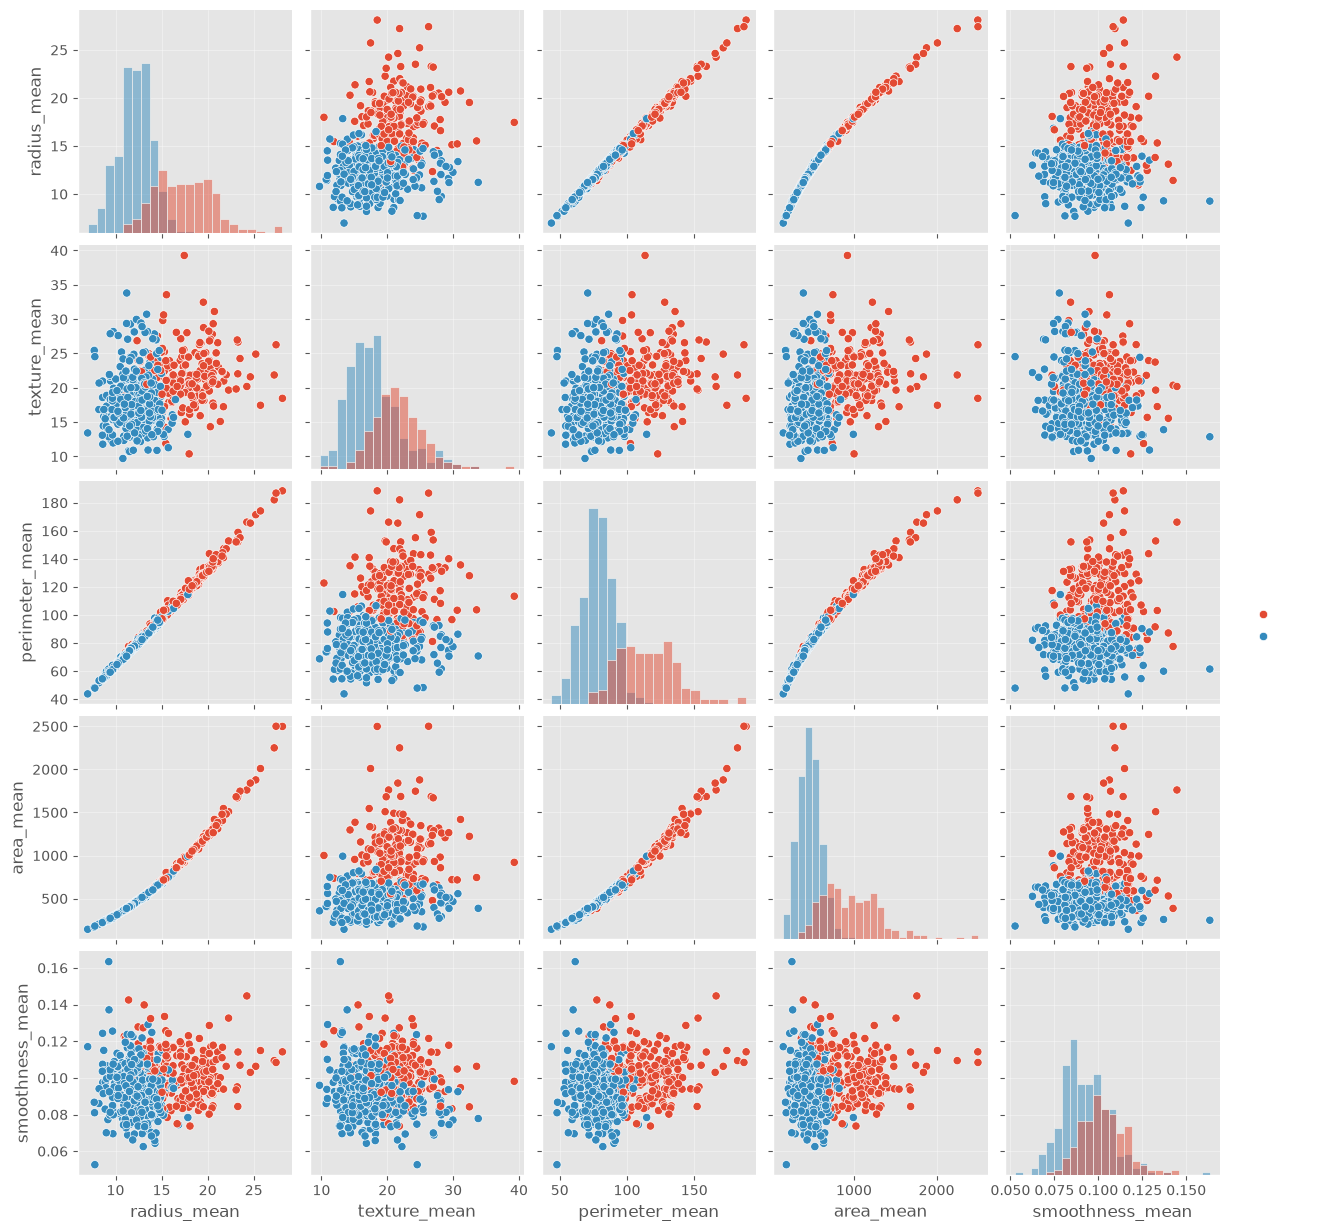

In [104]:
selected_features = ['radius_mean','texture_mean','perimeter_mean','area_mean','smoothness_mean','diagnosis']

sns.pairplot(dataset[selected_features],hue='diagnosis',diag_kind='hist')

plt.show()

# STEP 4: Model Building

For this dataset, a relatively simple ANN is recommended because there are only 30 inputs features and 569 observations bearing in mind that a very deep network would unncessarily increase the risk of overfitting. Using X_train_scaled, X_test_scaled, y_train, and y_test developed at the preprocessing to build ANN model

In [105]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build the ANN model
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    #To learn nonlinear relationships in the hidden layers
    Dense(8, activation='relu'),
    #For binary classification for value between 0 and 1
    Dense(1, activation='sigmoid')
])

# Display the model architecture
model.summary()

C:\Users\Kayode Ogunyemi\PycharmProjects\WelcomeScreen\.venv\Lib\site-packages\keras\src\layers\core\dense.py:102: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

INTERPRETATION - The dataset contains 30 predictor variables and 569 observations, making a relatively shallow network appropriate. Two hidden layers were selected to allow the model to learn nonlinear relationships among the tumor characteristics without introducing excessive architectural complexity

In [106]:
# Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Adam: adaptive optimizer that adjusts the model weights efficiently.
Learning rate = 0.001: a commonly used starting point for Adam and appropriate for a small ANN.
Binary cross-entropy: appropriate because the target has two classes, benign and malignant.
Accuracy: provides an initial measure of classification performance.

# STEP 5: Model Training

In [112]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau

### Learning Rate
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.00001,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9945 - loss: 0.0473 - val_accuracy: 0.9670 - val_loss: 0.1036 - learning_rate: 0.0010
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9945 - loss: 0.0460 - val_accuracy: 0.9670 - val_loss: 0.1037 - learning_rate: 0.0010
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9945 - loss: 0.0445 - val_accuracy: 0.9670 - val_loss: 0.1039 - learning_rate: 0.0010
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9945 - loss: 0.0432 - val_accuracy: 0.9670 - val_loss: 0.1041 - learning_rate: 0.0010
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9945 - loss: 0.0419 - val_accuracy: 0.9670 - val_loss: 0.1044 - learning_rate: 0.0010
Epoch 6/100
 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0244
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9945 - loss: 0.0407 - val

INTERPRETATION - Output shows that the ANN model is learning the training data very well, but its performance on the validation data is no longer improving. This is an early sign of overfitting, which explains why ReduceLROnPlateau is reducing the learning rate as shown in the output above

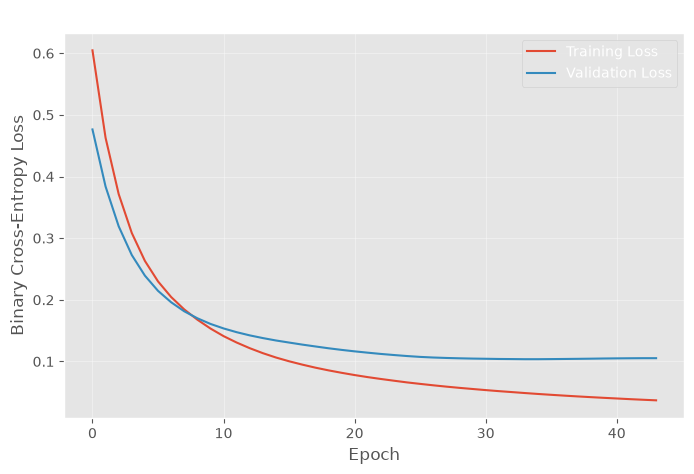

In [111]:
#Monitoring Training & Validation Losses
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.show()

INTERPRETATION - My observation is suggest decrease both in the TRAINING and VALIDATION loss which is a good indicator

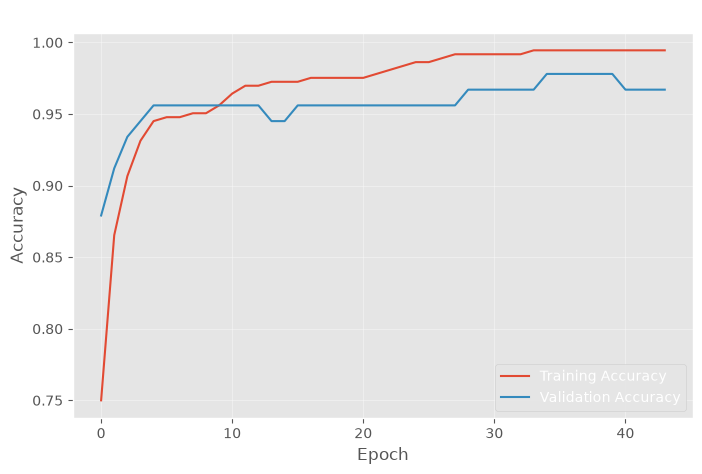

In [109]:
### Monitor Accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

INTERPRETATION - From the plots below, we could see that TRAINING ACCURACY is about 99.9% while VALIDATION ACCURACY is 98.4% approx which would be a generally reasonable result or outcome

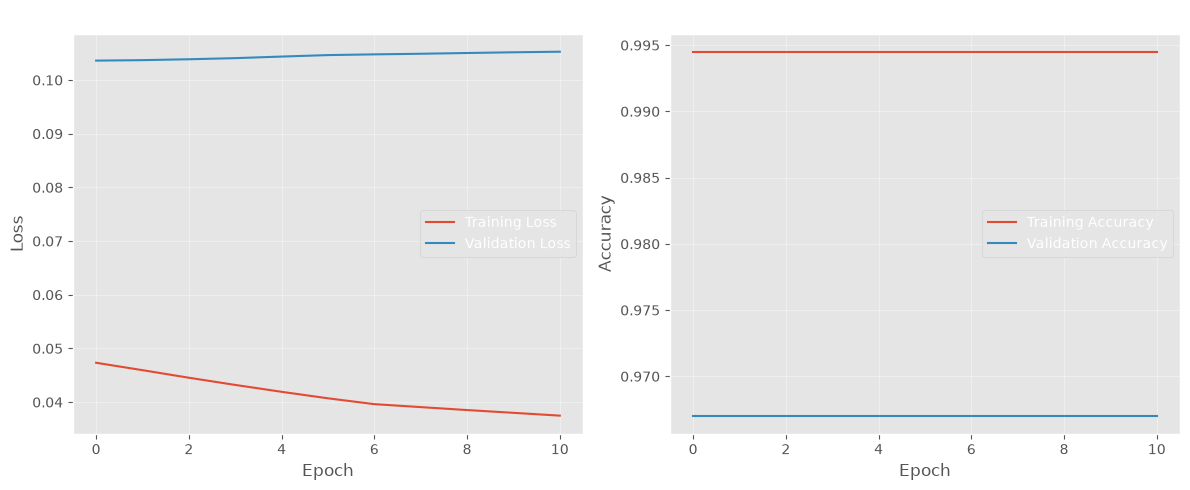

In [113]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

Test Accuracy is 98.25%

In [114]:
test_loss, test_accuracy = model.evaluate(
    X_test_scaled, y_test, verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2%}")

Test Loss: 0.0632
Test Accuracy: 98.25%


# STEP 6: Model Evaluation

ANN MODEL EVALUATION
-----------------------------------
Accuracy:  0.9825 (98.25%)
Precision: 0.9762
Recall:    0.9762
F1-score:  0.9762
ROC-AUC:   0.9983

Classification Report:
              precision    recall  f1-score   support

      Benign       0.99      0.99      0.99        72
   Malignant       0.98      0.98      0.98        42

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



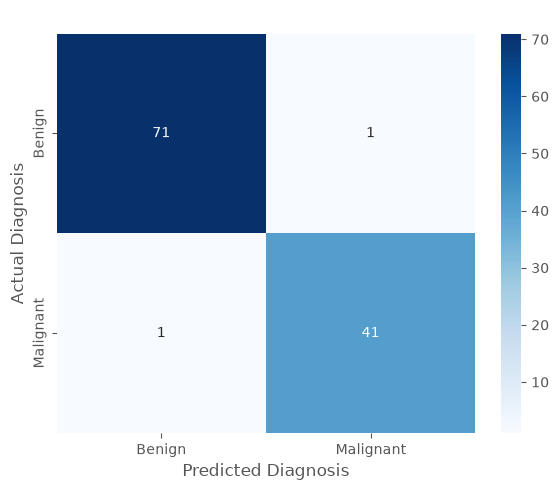

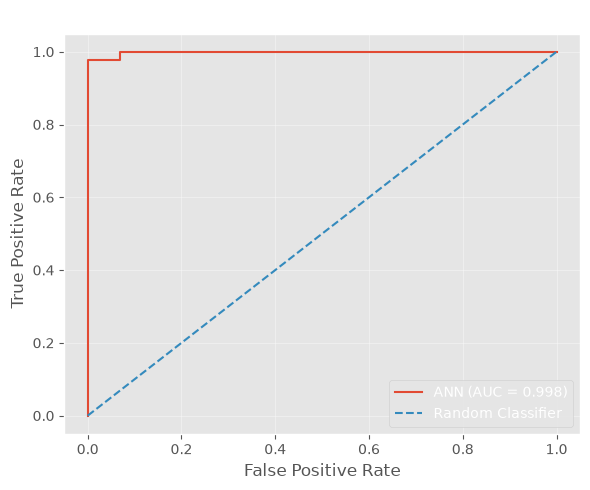

In [115]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# Generate predicted probabilities for malignant cases
y_prob = model.predict(X_test_scaled, verbose=0).ravel()

# Convert probabilities to binary predictions using a 0.5 threshold
y_pred = (y_prob >= 0.5).astype(int)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)

print("ANN MODEL EVALUATION")
print("-" * 35)
print(f"Accuracy:  {accuracy:.4f} ({accuracy:.2%})")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1],
    target_names=["Benign", "Malignant"],
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)
plt.title("ANN Confusion Matrix")
plt.xlabel("Predicted Diagnosis")
plt.ylabel("Actual Diagnosis")
plt.tight_layout()
plt.show()

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ANN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()


INTERPRETATION -
Accuracy = 98.25% which means about 112 of 114 predictions were correct.
Precision = 0.9762	which represent about 97.62% of predicted malignant cases were actually malignant.
Recall	= 0.976 approximately 97.62% of actual malignant cases were correctly identified.
F1-score = 0.9762 suggests a strong balance between precision and recall.
ROC-AUC = 0.998 It demonstrated an excellent ability to distinguish between the two classes across thresholds.